# Dataset Exploration & Annotation Documentation
## Early Warning System for Forest Fire — Group 16
**CS437/CS5317/EE414/EE513 — Deep Learning, Spring 2026** Nausherwan Khan Arzani (27100384) · Saad Jamshaid Khan (27100159)

---

This notebook documents the refined dataset landscape for our three-stage training pipeline. We have streamlined Stage 1 to focus on four high-quality datasets that provide the necessary geographic and spectral diversity.

| Stage | Purpose | Datasets |
|---|---|---|
| **Stage 1 — Pretraining** | Large-scale daytime fire/smoke detection | D-Fire, FIgLib, FASDD, FIRESENSE |
| **Stage 2 — Nighttime Fine-tuning** | Low-light and IR-based fire detection | FLAME 2 (RGB + IR) |
| **Stage 3 — Domain Adaptation** | Site-specific PTZ camera footage | WWF Custom Dataset (Active Development) |

For each dataset, we cover: origin and access, number of classes, train/val/test splits, sample images, annotation format, and relevance to our research question.

## 0. Setup & Dependencies

In [2]:
# ── Install all required packages ────────────────────────────────────────────
!pip install roboflow opencv-python matplotlib seaborn pandas numpy Pillow tqdm kagglehub --quiet

import os, sys, json, glob, random, shutil, zipfile
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
import seaborn as sns
import cv2
from PIL import Image
from tqdm import tqdm

# Consistent style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ── Global config ─────────────────────────────────────────────────────────────
# Set your Roboflow API key here (get it from https://app.roboflow.com → Settings → API)
RF_API_KEY = "YOUR_ROBOFLOW_API_KEY_HERE"

# Set your Kaggle credentials (https://www.kaggle.com/settings → API → Create Token)
os.environ['KAGGLE_USERNAME'] = "YOUR_KAGGLE_USERNAME"
os.environ['KAGGLE_KEY']      = "YOUR_KAGGLE_KEY"

DATASETS_DIR = Path('./datasets')
DATASETS_DIR.mkdir(exist_ok=True)

print('Environment ready.')


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Environment ready.


---
## 0.1 Video Frame Extraction Utility

A reusable helper for pulling training/EDA frames from any video file. Used for FIRESENSE and FLAME 2 clips.

In [3]:
# ── Video frame extraction utility ───────────────────────────────────────────
def extract_frames(
    video_path,
    output_dir,
    every_n_frames: int = 30,
    max_frames: int = None,
    prefix: str = "frame",
    img_format: str = "jpg",
    resize: tuple = None,
) -> list:
    """
    Extract frames from a video file for training or EDA.

    Parameters
    ----------
    video_path    : str or Path — input video file
    output_dir    : str or Path — folder to write frames into (created if absent)
    every_n_frames: save 1 frame every N frames (default 30 ≈ 1 fps @ 30 fps video)
    max_frames    : hard cap on total saved frames (None = no limit)
    prefix        : filename prefix, e.g. 'frame' → 'frame_00042.jpg'
    img_format    : 'jpg' or 'png'
    resize        : (width, height) to resize before saving, or None to keep original

    Returns
    -------
    List of saved file paths.
    """
    video_path = Path(video_path)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise ValueError(f"Cannot open video: {video_path}")

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps_video    = cap.get(cv2.CAP_PROP_FPS)
    width        = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height       = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    print(f"  Video : {video_path.name}")
    print(f"  Total : {total_frames} frames @ {fps_video:.1f} fps  ({width}x{height})")
    print(f"  Saving: every {every_n_frames} frames → ~{total_frames // every_n_frames} output frames")

    saved_paths = []
    frame_idx   = 0
    saved_count = 0

    with tqdm(total=total_frames, unit="frame") as pbar:
        while True:
            ret, frame = cap.read()
            if not ret:
                break

            if frame_idx % every_n_frames == 0:
                if resize:
                    frame = cv2.resize(frame, resize)

                fname = output_dir / f"{prefix}_{frame_idx:06d}.{img_format}"
                cv2.imwrite(str(fname), frame)
                saved_paths.append(fname)
                saved_count += 1

                if max_frames and saved_count >= max_frames:
                    print(f"  Reached max_frames={max_frames}. Stopping early.")
                    break

            frame_idx += 1
            pbar.update(1)

    cap.release()
    print(f"  Saved : {saved_count} frames → {output_dir}")
    return saved_paths


# ── Example usage (commented out until you have a video file) ─────────────────
# paths = extract_frames(
#     video_path   = "./datasets/firesense/clip_01.avi",
#     output_dir   = "./datasets/firesense_frames/clip_01/",
#     every_n_frames = 15,    # sample every 15 frames (~2fps for 30fps clip)
#     max_frames   = 200,     # cap at 200 frames per clip for EDA
#     prefix       = "fire",
# )
# print(f"Extracted {len(paths)} frames")
print("extract_frames() utility loaded.")

extract_frames() utility loaded.


---
## 1. Dataset Landscape Overview

The table below summarises all datasets used in this project. Together they cover RGB daytime, RGB nighttime, thermal/IR, fixed-camera, and aerial viewpoints — addressing each of the three core gaps identified in our SOA survey.

In [4]:
dataset_overview = pd.DataFrame([
    {'Dataset': 'D-Fire',             'Size': '21,527 images',      'Modality': 'RGB',             'Classes': 'fire, smoke',            'Task': 'Detection (YOLO)',            'Split': '70/15/15',                        'Access': 'Roboflow',                  'Stage': 'Pretraining',        'Key role': 'Primary compact-model benchmark'},
    {'Dataset': 'FIgLib',             'Size': '24,800 images',      'Modality': 'RGB',             'Classes': 'smoke (binary)',          'Task': 'Classification / Detection',  'Split': '315 sequences / 101 cameras',     'Access': 'HPWREN (registration)',      'Stage': 'Pretraining',        'Key role': 'Closest public analogue to PTZ setup'},
    {'Dataset': 'SKLFS-WildFire',     'Size': '350,000+ images',    'Modality': 'RGB',             'Classes': 'smoke (early-stage)',     'Task': 'Detection',                   'Split': 'Train / Val',                     'Access': 'arXiv:2311.10116 (authors)','Stage': 'Pretraining',        'Key role': 'Largest early-stage wildfire dataset'},
    {'Dataset': 'FASDD',              'Size': '120,000+ images',    'Modality': 'RGB',             'Classes': 'fire, smoke',            'Task': 'Detection (COCO bbox)',        'Split': 'Train / Val / Test',              'Access': 'Kaggle (yuulind)',           'Stage': 'Pretraining',        'Key role': 'Geographic diversity / OOD testing'},
    {'Dataset': 'Wildfire Smoke',     'Size': '~737 images',        'Modality': 'RGB',             'Classes': 'smoke',                  'Task': 'Detection (YOLO)',             'Split': 'Train / Val / Test',              'Access': 'Roboflow',                  'Stage': 'Pretraining',        'Key role': 'Curated early-smoke samples'},
    {'Dataset': 'FIRESENSE',          'Size': '49 video clips',     'Modality': 'RGB',             'Classes': 'fire, smoke',            'Task': 'Classification / Detection',   'Split': 'No fixed split',                  'Access': 'Roboflow / mklab',          'Stage': 'Pretraining',        'Key role': 'Heritage/urban hard negatives; video temporal data'},
    {'Dataset': 'FLAME 2',            'Size': '7 RGB + 7 IR videos','Modality': 'RGB + Thermal IR','Classes': 'fire (binary)',           'Task': 'Classification / Segmentation','Split': '39,375 train / 8,617 test',       'Access': 'IEEE DataPort',             'Stage': 'Nighttime Fine-tuning','Key role': 'Only public paired RGB-IR wildfire dataset'},
    {'Dataset': 'WWF PTZ (Custom)',   'Size': 'TBD',                'Modality': 'RGB',             'Classes': 'fire, smoke, cloud',     'Task': 'Detection (YOLO)',             'Split': 'TBD (hold out 1 camera site)',    'Access': 'Internal — WWF Pakistan',   'Stage': 'Domain Adaptation',  'Key role': 'South Asian forest terrain; only dataset of its kind'},
])

pd.set_option('display.max_colwidth', 60)
dataset_overview.set_index('Dataset', inplace=True)
print('=== All Datasets — Project Pipeline ===')
dataset_overview

=== All Datasets — Project Pipeline ===


,Size,Modality,Classes,Task,Split,Access,Stage,Key role
Dataset,,,,,,,,
D-Fire,"21,527 images",RGB,"fire, smoke",Detection (YOLO),70/15/15,Roboflow,Pretraining,Primary compact-model benchmark
FIgLib,"24,800 images",RGB,smoke (binary),Classification / Detection,315 sequences / 101 cameras,HPWREN (registration),Pretraining,Closest public analogue to PTZ setup
SKLFS-WildFire,"350,000+ images",RGB,smoke (early-stage),Detection,Train / Val,arXiv:2311.10116 (authors),Pretraining,Largest early-stage wildfire dataset
FASDD,"120,000+ images",RGB,"fire, smoke",Detection (COCO bbox),Train / Val / Test,Kaggle (yuulind),Pretraining,Geographic diversity / OOD testing
Wildfire Smoke,~737 images,RGB,smoke,Detection (YOLO),Train / Val / Test,Roboflow,Pretraining,Curated early-smoke samples
FIRESENSE,49 video clips,RGB,"fire, smoke",Classification / Detection,No fixed split,Roboflow / mklab,Pretraining,Heritage/urban hard negatives; video temporal data
FLAME 2,7 RGB + 7 IR videos,RGB + Thermal IR,fire (binary),Classification / Segmentation,"39,375 train / 8,617 test",IEEE DataPort,Nighttime Fine-tuning,Only public paired RGB-IR wildfire dataset
WWF PTZ (Custom),TBD,RGB,"fire, smoke, cloud",Detection (YOLO),TBD (hold out 1 camera site),Internal — WWF Pakistan,Domain Adaptation,South Asian forest terrain; only dataset of its kind


---
## 2. Stage 1 — Pretraining Datasets

### 2.1 D-Fire (Primary Benchmark Dataset)

**Origin:** Pedro Vinícius A. B. de Venâncio et al., *"An automatic fire detection system based on deep convolutional neural networks"*. Available via Roboflow Universe.

**Why this dataset:**  
D-Fire is the standard benchmark for compact fire/smoke models. It has two independent object classes — `fire` and `smoke` — enabling us to measure the fire/smoke recall gap (recall 0.9 vs 0.7) quantified in the literature.

**Classes:** 2 — `fire` (class 0), `smoke` (class 1)  
**Annotation format:** YOLO format (normalised `cx cy w h` per line in `.txt` files)

In [17]:
# ── D-Fire: Download from GitHub (no account needed) ─────────────────────────
# The official repo uses Git LFS for the image zips.
# On first run this will take a few minutes (~1.5 GB).

DFIRE_ROOT = DATASETS_DIR / 'dfire/data'

if not DFIRE_ROOT.exists():
    # 1. Clone repo (fast — just metadata + LFS pointers)
    !git clone https://github.com/gaialab/DFireDataset.git {DFIRE_ROOT}
    
    # 2. Pull actual image data via LFS
    # If git-lfs is not installed: pip install git-lfs  OR  brew install git-lfs
    !git -C {DFIRE_ROOT} lfs pull
    print("D-Fire downloaded.")
else:
    print(f"D-Fire already present at: {DFIRE_ROOT}")

# Verify
for split in ['train', 'val', 'test']:
    img_dir = DFIRE_ROOT / split / 'images'
    lbl_dir = DFIRE_ROOT / split / 'labels'
    imgs = list(img_dir.glob('*.jpg')) + list(img_dir.glob('*.png')) if img_dir.exists() else []
    lbls = list(lbl_dir.glob('*.txt')) if lbl_dir.exists() else []
    print(f"  {split:6s}: {len(imgs):6d} images | {len(lbls):6d} labels")

D-Fire already present at: datasets\dfire\data
  train :  14122 images |  14122 labels
  val   :   3099 images |   3099 labels
  test  :   4306 images |   4306 labels


In [18]:
# ── D-Fire: Parse annotations ────────────────────────────────────────────────
CLASS_NAMES = {0: 'fire', 1: 'smoke'}

def parse_yolo_labels(root, splits=('train', 'valid', 'test')):
    records = []
    for split in splits:
        label_dir = root / split / 'labels'
        if not label_dir.exists():
            continue
        for lbl_path in label_dir.glob('*.txt'):
            with open(lbl_path) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) == 5:
                        cls = int(parts[0])
                        cx, cy, w, h = map(float, parts[1:])
                        records.append({'split': split, 'class_id': cls,
                                        'cx': cx, 'cy': cy, 'bw': w, 'bh': h,
                                        'area': w * h})
    return pd.DataFrame(records)

df_dfire = parse_yolo_labels(DFIRE_ROOT)
df_dfire['class_name'] = df_dfire['class_id'].map(CLASS_NAMES)
print(f'Total bounding box annotations: {len(df_dfire):,}')
print(df_dfire.groupby(['split', 'class_name']).size().unstack(fill_value=0))

Total bounding box annotations: 22,625
class_name  fire  smoke
split                  
test        2315   2878
train       7794   9638


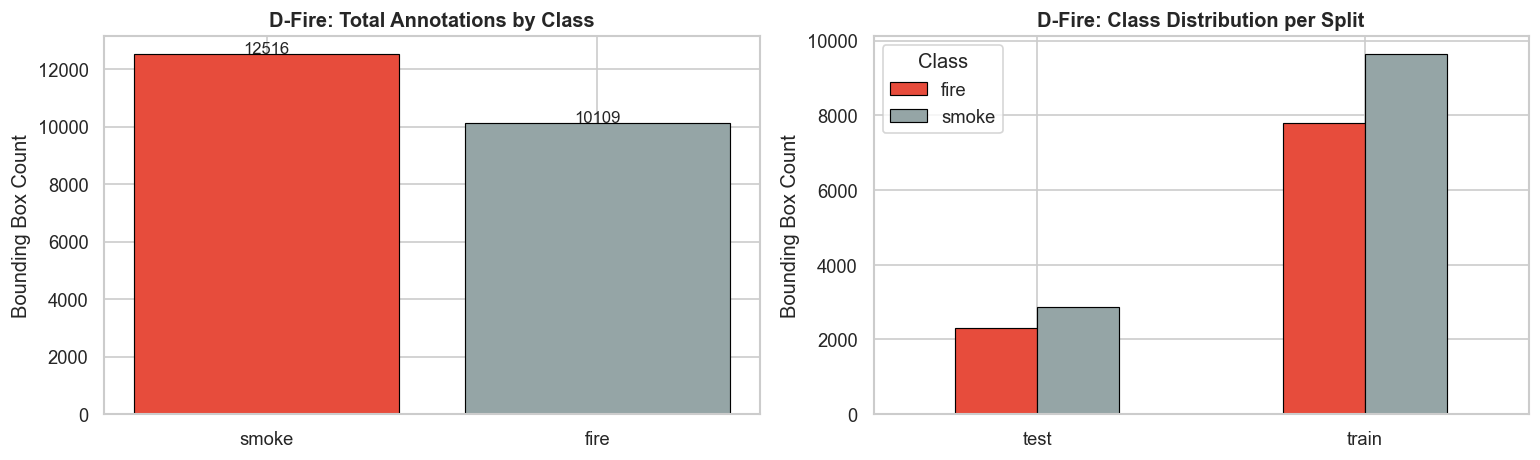

In [19]:
# ── D-Fire: Class distribution chart ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

class_counts = df_dfire['class_name'].value_counts()
axes[0].bar(class_counts.index, class_counts.values,
            color=['#e74c3c', '#95a5a6'], edgecolor='black', linewidth=0.7)
axes[0].set_title('D-Fire: Total Annotations by Class', fontweight='bold')
axes[0].set_ylabel('Bounding Box Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontsize=10)

split_class = df_dfire.groupby(['split', 'class_name']).size().unstack(fill_value=0)
split_class.plot(kind='bar', ax=axes[1], color=['#e74c3c', '#95a5a6'],
                 edgecolor='black', linewidth=0.7)
axes[1].set_title('D-Fire: Class Distribution per Split', fontweight='bold')
axes[1].set_ylabel('Bounding Box Count')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Class')

plt.tight_layout()
plt.savefig('dfire_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

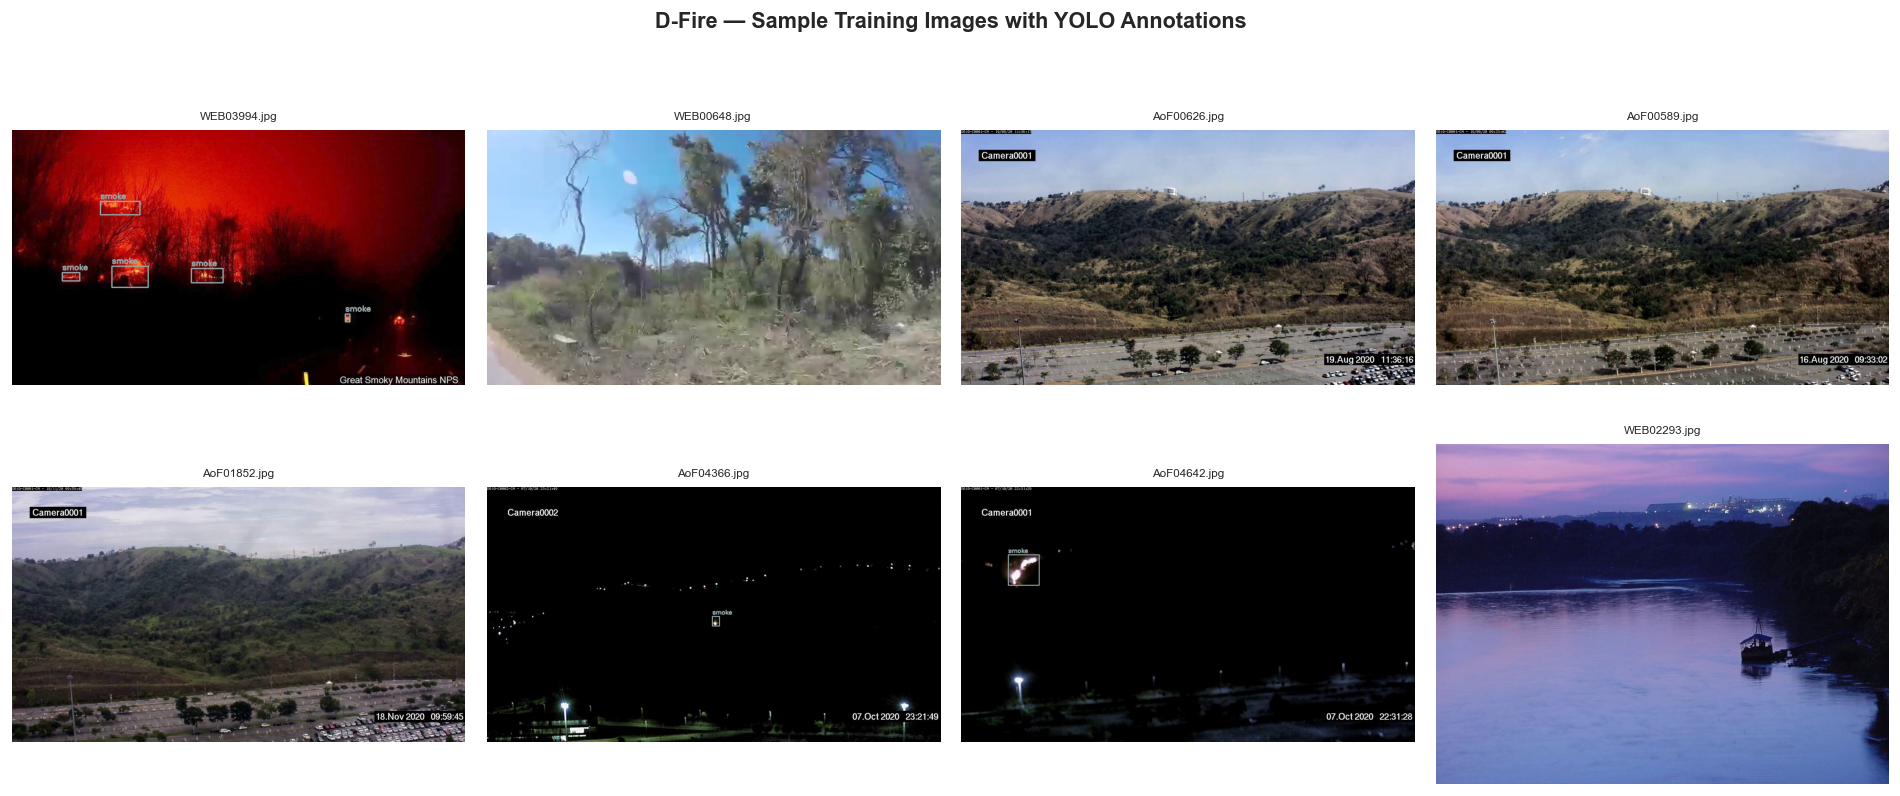

In [ ]:
# ── D-Fire: Sample images ──────────────────────────────────────────
COLORS = {0: (231, 76, 60), 1: (149, 165, 166)}  # fire=red, smoke=grey

def draw_yolo_boxes(img_path, label_path, class_names, colors):
    img = cv2.imread(str(img_path))
    if img is None:
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    if label_path.exists():
        with open(label_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) != 5:
                    continue
                cls_id = int(parts[0])
                cx, cy, bw, bh = map(float, parts[1:])
                x1 = int((cx - bw/2) * w); y1 = int((cy - bh/2) * h)
                x2 = int((cx + bw/2) * w); y2 = int((cy + bh/2) * h)
                color = colors.get(cls_id, (255, 255, 0))
                cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
                label = class_names.get(cls_id, str(cls_id))
                cv2.putText(img, label, (x1, y1 - 6), cv2.FONT_HERSHEY_SIMPLEX, 0.55, color, 2)
    return img

train_imgs = sorted((DFIRE_ROOT / 'train' / 'images').glob('*.jpg'))
sample_imgs = random.sample(train_imgs, min(8, len(train_imgs)))

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle('D-Fire — Sample Training Images with YOLO Annotations', fontsize=13, fontweight='bold')

for ax, img_path in zip(axes.flat, sample_imgs):
    lbl_path = DFIRE_ROOT / 'train' / 'labels' / (img_path.stem + '.txt')
    vis = draw_yolo_boxes(img_path, lbl_path, CLASS_NAMES, COLORS)
    if vis is not None:
        ax.imshow(vis)
    ax.axis('off')
    ax.set_title(img_path.name[:20], fontsize=7)

plt.tight_layout()
plt.savefig('dfire_samples.png', dpi=150, bbox_inches='tight')
plt.show()

train: 100%|██████████| 300/300 [00:08<00:00, 36.11it/s]


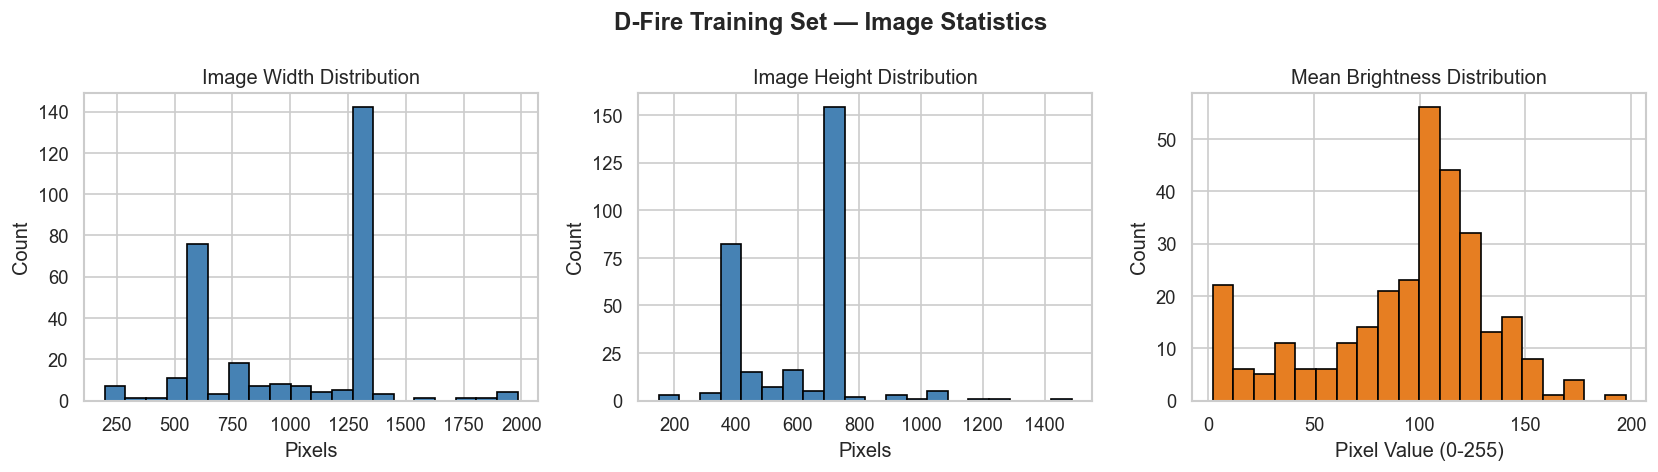

        width  height  aspect  brightness
count   300.0   300.0   300.0       300.0
mean   1012.0   599.6     1.7        94.3
std     346.8   194.7     0.2        40.5
min     198.0   150.0     0.5         2.1
25%     640.0   360.0     1.8        76.6
50%    1280.0   720.0     1.8       103.5
75%    1280.0   720.0     1.8       118.9
max    1984.0  1488.0     2.0       197.4


In [22]:
# ── D-Fire: Image statistics (resolution, brightness) ────────────────────────
def compute_image_stats(img_dir, n_sample=300):
    paths = list(img_dir.glob('*.jpg')) + list(img_dir.glob('*.png'))
    paths = random.sample(paths, min(n_sample, len(paths)))
    stats = []
    for p in tqdm(paths, desc=str(img_dir.parent.name)):
        img = cv2.imread(str(p), cv2.IMREAD_COLOR)
        if img is None:
            continue
        h, w = img.shape[:2]
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        stats.append({'width': w, 'height': h, 'aspect': round(w/h, 2),
                      'brightness': gray.mean()})
    return pd.DataFrame(stats)

stats_train = compute_image_stats(DFIRE_ROOT / 'train' / 'images')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].hist(stats_train['width'],      bins=20, color='steelblue', edgecolor='black')
axes[0].set_title('Image Width Distribution');   axes[0].set_xlabel('Pixels')
axes[1].hist(stats_train['height'],     bins=20, color='steelblue', edgecolor='black')
axes[1].set_title('Image Height Distribution');  axes[1].set_xlabel('Pixels')
axes[2].hist(stats_train['brightness'], bins=20, color='#e67e22',   edgecolor='black')
axes[2].set_title('Mean Brightness Distribution'); axes[2].set_xlabel('Pixel Value (0-255)')
for ax in axes:
    ax.set_ylabel('Count')

fig.suptitle('D-Fire Training Set — Image Statistics', fontweight='bold')
plt.tight_layout()
plt.savefig('dfire_stats.png', dpi=150, bbox_inches='tight')
plt.show()
print(stats_train.describe().round(1))

---
### 2.2 FIgLib — Fixed-View Camera Dataset (Closest PTZ Analogue)

**Origin:** Dewangan et al., *Remote Sensing* 2022. HPWREN camera network, Southern California — 101 fixed-view cameras across 315 wildland fire sequences.  
**Access:** Free registration at [hpwren.ucsd.edu/HPWREN-FIgLib](http://hpwren.ucsd.edu/HPWREN-FIgLib/)

**Why this dataset:**  
FIgLib is architecturally closest to our PTZ deployment. Cameras are fixed at elevated positions looking across horizons — exactly the geometry where cloud/smoke confusion is worst.

**Classes:** Binary — `smoke` / `no smoke` (image-level label)  
**Size:** 24,800 high-resolution images  
**Split:** By fire event (prevents geographic leakage)

In [ ]:
# ── FIgLib: Structural summary (from paper) ──────────────────────────────────
# Download requires registration at http://hpwren.ucsd.edu/HPWREN-FIgLib/
FIGLIB_ROOT = Path(r"D:\datasets_dl\datasets\figlib\figlibs")
figlib_summary = pd.DataFrame([
    {'Split': 'Train', 'Fire sequences': 220, 'Images': '~17,400', 'Smoke frames': '~8,700'},
    {'Split': 'Val',   'Fire sequences':  47, 'Images':  '~3,700', 'Smoke frames': '~1,850'},
    {'Split': 'Test',  'Fire sequences':  48, 'Images':  '~3,700', 'Smoke frames': '~1,850'},
])
print('FIgLib Dataset — Split Summary (from published paper)')
print(figlib_summary.to_string(index=False))
print()
print('Note: Splits are by fire EVENT, not random image shuffle.')
print('This prevents the same camera view appearing in both train and test.')
print()
print('Class balance: ~50/50 smoke vs no-smoke (by design).')
print('Real deployment ratio is ~1 fire frame per ~10,000 non-fire frames.')

FIgLib Dataset — Split Summary (from published paper)
Split  Fire sequences  Images Smoke frames
Train             220 ~17,400       ~8,700
  Val              47  ~3,700       ~1,850
 Test              48  ~3,700       ~1,850

Note: Splits are by fire EVENT, not random image shuffle.
This prevents the same camera view appearing in both train and test.

Class balance: ~50/50 smoke vs no-smoke (by design).
Real deployment ratio is ~1 fire frame per ~10,000 non-fire frames.


In [ ]:
# ── FIgLib: Load and Label Images from Filenames ─────────────────────────────
def load_figlib_metadata(root_path):
    records = []
    # Find all .jpg files in your local folder
    image_paths = list(Path(root_path).rglob('*.jpg'))
    
    for p in image_paths:
        try:
            # Filename format: timestamp_offset.jpg (e.g., 1720455951_+00000.jpg)
            parts = p.stem.split('_')
            offset_str = parts[-1] 
            
            # Label based on sign: '+' is smoke, '-' is no smoke
            label = 'smoke' if '+' in offset_str else 'no_smoke'
            
            records.append({
                'path': p,
                'filename': p.name,
                'label': label,
                'offset': offset_str
            })
        except Exception:
            continue
            
    return pd.DataFrame(records)

# Create the dataframe
df_figlib = load_figlib_metadata(FIGLIB_ROOT)

print(f"Total FIgLib images found: {len(df_figlib)}")
print(df_figlib['label'].value_counts())

# ── FIgLib: Sample images ──────────────────────────────────────────
load_figlib_metadata(FIGLIB_ROOT)

Total FIgLib images found: 81
label
smoke       41
no_smoke    40
Name: count, dtype: int64


,path,filename,label,offset
0,D:\datasets_dl\datasets\figlib\figlibs\1497047247_-02400...,1497047247_-02400.jpg,no_smoke,-02400
1,D:\datasets_dl\datasets\figlib\figlibs\1497047307_-02340...,1497047307_-02340.jpg,no_smoke,-02340
2,D:\datasets_dl\datasets\figlib\figlibs\1497047367_-02280...,1497047367_-02280.jpg,no_smoke,-02280
3,D:\datasets_dl\datasets\figlib\figlibs\1497047427_-02220...,1497047427_-02220.jpg,no_smoke,-02220
4,D:\datasets_dl\datasets\figlib\figlibs\1497047487_-02160...,1497047487_-02160.jpg,no_smoke,-02160
...,...,...,...,...
76,D:\datasets_dl\datasets\figlib\figlibs\1497051807_+02160...,1497051807_+02160.jpg,smoke,+02160
77,D:\datasets_dl\datasets\figlib\figlibs\1497051867_+02220...,1497051867_+02220.jpg,smoke,+02220
78,D:\datasets_dl\datasets\figlib\figlibs\1497051927_+02280...,1497051927_+02280.jpg,smoke,+02280
79,D:\datasets_dl\datasets\figlib\figlibs\1497051987_+02340...,1497051987_+02340.jpg,smoke,+02340


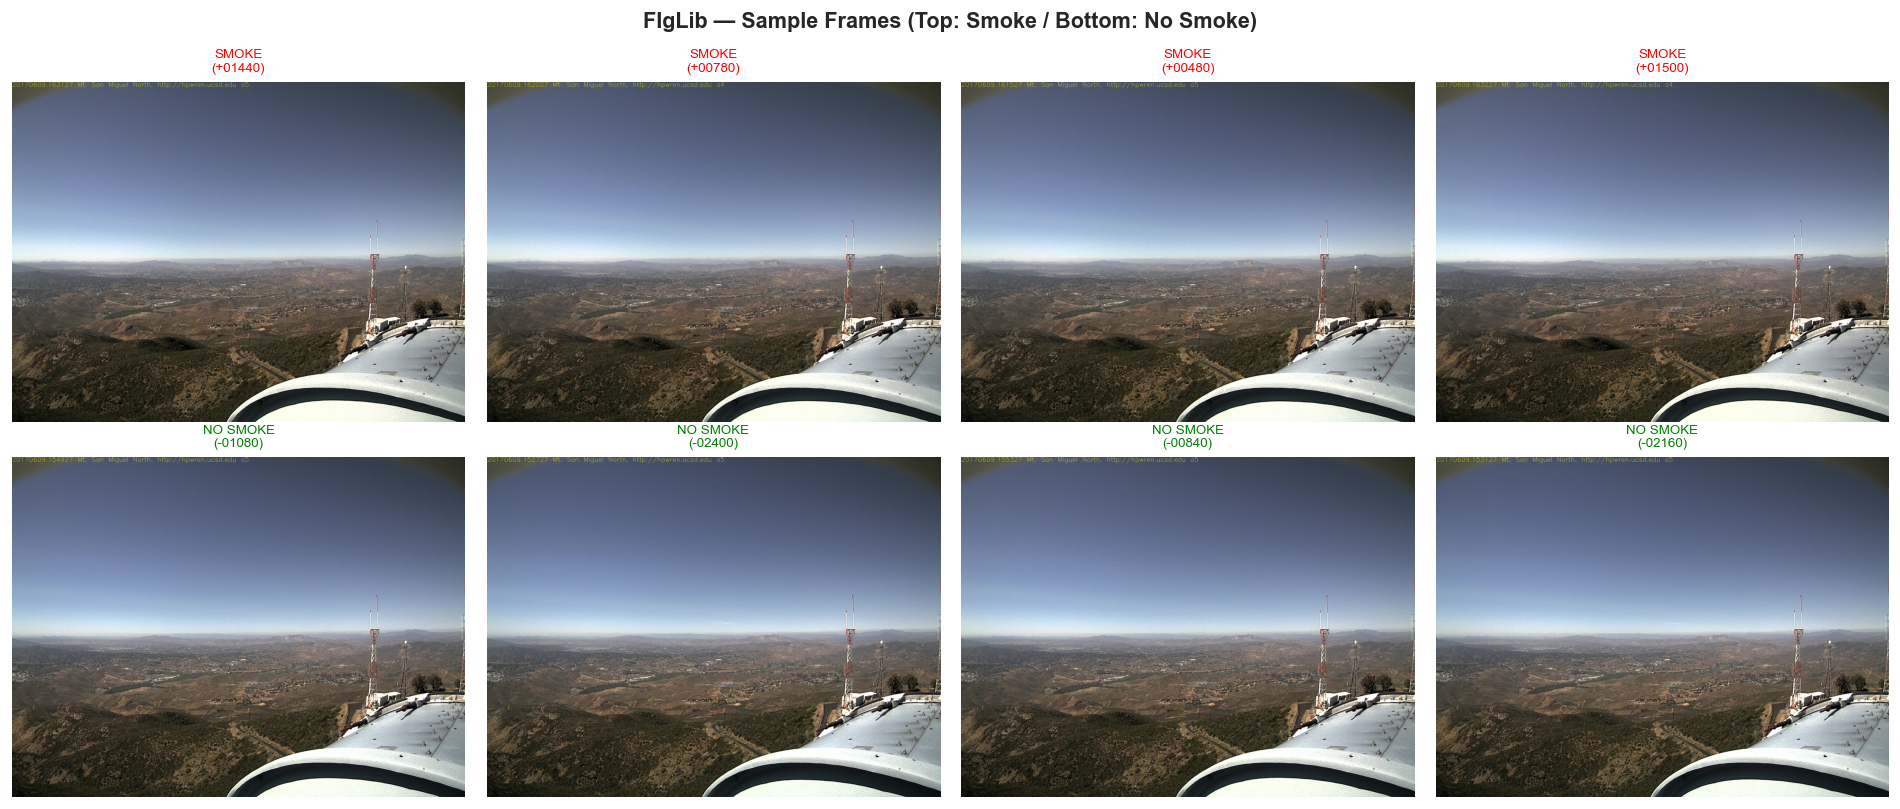

In [34]:

# ── FIgLib: Visualise Smoke vs. No-Smoke ─────────────────────────────────────
if not df_figlib.empty:
    # Filter for each class
    smoke_samples = df_figlib[df_figlib['label'] == 'smoke'].sample(n=min(4, len(df_figlib)))
    neg_samples   = df_figlib[df_figlib['label'] == 'no_smoke'].sample(n=min(4, len(df_figlib)))

    fig, axes = plt.subplots(2, 4, figsize=(16, 7))
    fig.suptitle('FIgLib — Sample Frames (Top: Smoke / Bottom: No Smoke)', 
                 fontsize=13, fontweight='bold')

    # Plot Smoke Samples
    for ax, (_, row) in zip(axes[0], smoke_samples.iterrows()):
        img = plt.imread(row['path'])
        ax.imshow(img); ax.set_title(f"SMOKE\n({row['offset']})", color='red', fontsize=8); ax.axis('off')

    # Plot No-Smoke Samples
    for ax, (_, row) in zip(axes[1], neg_samples.iterrows()):
        img = plt.imread(row['path'])
        ax.imshow(img); ax.set_title(f"NO SMOKE\n({row['offset']})", color='green', fontsize=8); ax.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print(f"No .jpg images found at {FIGLIB_ROOT}")

---
### 2.4 FASDD — Fire and Smoke Detection Dataset (COCO Format)

**Origin:** Publicly released; 120,000+ heterogeneous images from diverse geographic locations.  
**Access:** Kaggle — `yuulind/fasdd-cv-coco`  
**Kaggle page:** https://www.kaggle.com/datasets/yuulind/fasdd-cv-coco

**Annotation format:** **COCO JSON** (not YOLO). Each split has an `_annotations.coco.json` file with bounding boxes in `[x, y, width, height]` pixel format. A conversion step is needed before YOLO training.

**Why this dataset:**  
Used for generalisation testing because of its geographic diversity. Serves as an out-of-distribution evaluation set after PTZ fine-tuning.

**Dataset structure (on Kaggle):**
```
fasdd-cv-coco/
  train/
    images/           ← training images
    _annotations.coco.json
  valid/
    images/
    _annotations.coco.json
  test/
    images/
    _annotations.coco.json
```

In [ ]:
import json
import random
from pathlib import Path
from collections import defaultdict
import kagglehub

# 1. Setup - Use Path objects consistently
BASE_DIR = Path('.')
DATASETS_DIR = BASE_DIR / 'datasets'
FASDD_SAMPLE_DIR = DATASETS_DIR / 'fasdd_samples'
FASDD_SAMPLE_DIR.mkdir(parents=True, exist_ok=True)

FASDD_HANDLE = "yuulind/fasdd-cv-coco"
FASDD_SPLIT = "test"  # Options: test, train, val
N_SAMPLE_IMAGES = 12

# ── Step 1: Download the annotation JSON ──────────────────────────────────────
# Corrected to match your screenshot: annotations/test.json
ann_remote_path = f"annotations/{FASDD_SPLIT}.json"
print(f"Step 1: Downloading {ann_remote_path}...")

try:
    # This downloads only the JSON file to your local cache
    ann_local_cache = kagglehub.dataset_download(FASDD_HANDLE, path=ann_remote_path)
    ann_path = Path(ann_local_cache)
    
    # Logic to handle if kagglehub returns the directory or the file
    if ann_path.is_dir():
        ann_path = ann_path / f"{FASDD_SPLIT}.json"
        
    print(f"   Annotation file ready at: {ann_path}")

    # ── Step 2: Parse COCO JSON to get image list ─────────────────────────────
    with open(ann_path) as f:
        coco_data = json.load(f)

    images_meta = coco_data['images']
    annotations = coco_data['annotations']
    categories = {c['id']: c['name'] for c in coco_data['categories']}

    # Count annotations per image to ensure we sample images that actually have boxes
    ann_per_image = defaultdict(list)
    for ann in annotations:
        ann_per_image[ann['image_id']].append(ann)

    # Filter for images that aren't empty
    annotated_ids = [img['id'] for img in images_meta if len(ann_per_image[img['id']]) > 0]
    
    # Randomly select sample IDs
    selected_ids = random.sample(annotated_ids, min(N_SAMPLE_IMAGES, len(annotated_ids)))
    sample_meta = [img for img in images_meta if img['id'] in selected_ids]

    print(f"\nStep 2: Parsed {len(images_meta)} images. Sampling {len(sample_meta)}...")

    # ── Step 3: Download the individual images ────────────────────────────────
    for img in sample_meta:
        # Construct the Kaggle path: images/test/FILENAME
        remote_img_path = f"images/{FASDD_SPLIT}/{img['file_name']}"
        local_img_path = kagglehub.dataset_download(FASDD_HANDLE, path=remote_img_path)
        print(f"   Retrieved: {img['file_name']}")

except Exception as e:
    print(f"Error: {e}")

Step 1: Downloading annotations/test.json...


100%|██████████| 4.50M/4.50M [00:00<00:00, 212MB/s]

   Annotation file ready at: C:\Users\NausherwanKhanArzani\.cache\kagglehub\datasets\yuulind\fasdd-cv-coco\versions\2\annotations\test.json



Step 2: Parsed 15884 images. Sampling 12...


100%|██████████| 7.13k/7.13k [00:00<00:00, 3.50MB/s]

...

   Retrieved: fire_CV004215.jpg


100%|██████████| 78.2k/78.2k [00:01<00:00, 77.3kB/s]


   Retrieved: smoke_CV010491.jpg


100%|██████████| 81.3k/81.3k [00:01<00:00, 82.1kB/s]

   Retrieved: smoke_CV013971.jpg


In [ ]:
# ── FASDD: Download sampled images (CORRECTED PATHS) ──────────────────────────
print(f"Step 3: Downloading {len(sample_meta)} sample images from Kaggle...")

FASDD_IMG_DIR = FASDD_SAMPLE_DIR / 'images'
FASDD_IMG_DIR.mkdir(exist_ok=True)

# Save annotation subset alongside images
sampled_ids = {img['id'] for img in sample_meta}
sample_anns = [a for a in annotations if a['image_id'] in sampled_ids]

sample_coco = {
    'images': sample_meta,
    'annotations': sample_anns,
    'categories': coco_data['categories']
}
with open(FASDD_SAMPLE_DIR / 'sample_annotations.coco.json', 'w') as f:
    json.dump(sample_coco, f, indent=2)

downloaded = []
for img_meta in tqdm(sample_meta, desc="Downloading images"):
    fname   = img_meta['file_name']
    
    # ── FIXED PATH ──────────────────────────────────────────────────────────
    # Old path: f"{FASDD_SPLIT}/images/{fname}" -> "test/images/..."
    # New path: f"images/{FASDD_SPLIT}/{fname}" -> "images/test/..."
    remote  = f"images/{FASDD_SPLIT}/{fname}" 
    # ────────────────────────────────────────────────────────────────────────
    
    dest    = FASDD_IMG_DIR / fname

    if dest.exists():
        downloaded.append(dest)
        continue
    try:
        # Fetch the file from Kaggle
        cached = kagglehub.dataset_download(FASDD_HANDLE, path=remote)
        cached = Path(cached)
        
        # If kagglehub returns a directory, locate the file inside it
        if cached.is_dir():
            candidates = list(cached.rglob(fname))
            cached = candidates[0] if candidates else cached / fname
        
        # Copy to your local project directory
        shutil.copy(cached, dest)
        downloaded.append(dest)
    except Exception as e:
        print(f"  Warning: could not fetch {fname}: {e}")

print(f"\nDownloaded {len(downloaded)} / {len(sample_meta)} images to {FASDD_IMG_DIR}")

Step 3: Downloading 12 sample images from Kaggle...



Downloaded 12 / 12 images to datasets\fasdd_samples\images


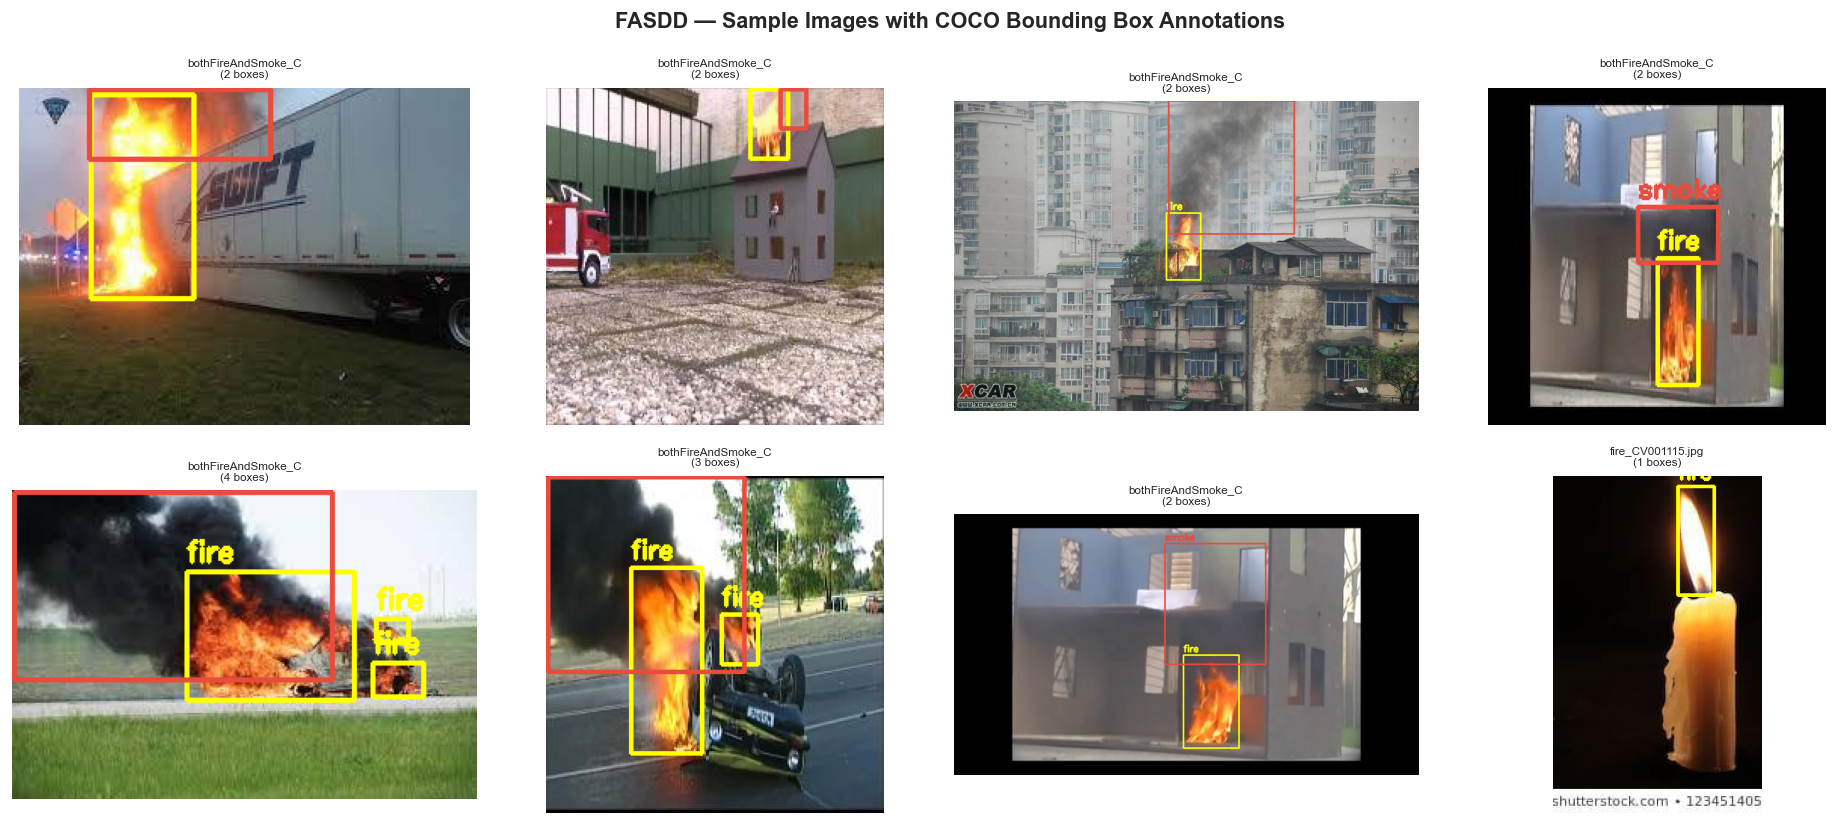

In [ ]:
# ── FASDD: Visualise COCO annotations on sample images ───────────────────────
CAT_COLORS = {1: (231, 76, 60), 2: (149, 165, 166)}  # fire=red, smoke=grey
# (check your actual category IDs from the printed `categories` dict above)

def draw_coco_boxes(img_path, img_id, ann_per_image, categories, cat_colors):
    img = cv2.imread(str(img_path))
    if img is None:
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h_img, w_img = img.shape[:2]

    for ann in ann_per_image.get(img_id, []):
        cat_name  = categories[ann['category_id']]
        x, y, w, bh = [int(v) for v in ann['bbox']]   # COCO: [x_min, y_min, width, height]
        x2, y2    = x + w, y + bh
        color     = cat_colors.get(ann['category_id'], (255, 255, 0))
        cv2.rectangle(img, (x, y), (x2, y2), color, 2)
        cv2.putText(img, cat_name, (x, y - 6), cv2.FONT_HERSHEY_SIMPLEX, 0.55, color, 2)
    return img

# Build image_id → filepath lookup
id_to_path = {img['id']: FASDD_IMG_DIR / img['file_name'] for img in sample_meta}

n_show = min(8, len(sample_meta))
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle('FASDD — Sample Images with COCO Bounding Box Annotations', fontsize=13, fontweight='bold')

for ax, img_meta in zip(axes.flat, list(id_to_path.items())[:n_show]):
    img_id, img_path = img_meta
    vis = draw_coco_boxes(img_path, img_id, ann_per_image, categories, CAT_COLORS)
    if vis is not None:
        ax.imshow(vis)
    n_ann = len(ann_per_image.get(img_id, []))
    ax.set_title(f"{img_path.name[:18]}\n({n_ann} boxes)", fontsize=7)
    ax.axis('off')

plt.tight_layout()
plt.savefig('fasdd_samples.png', dpi=150, bbox_inches='tight')
plt.show()

FASDD test split — annotation breakdown:
            count  mean_area
class_name                  
fire         9022    24274.6
smoke        8220    75262.9


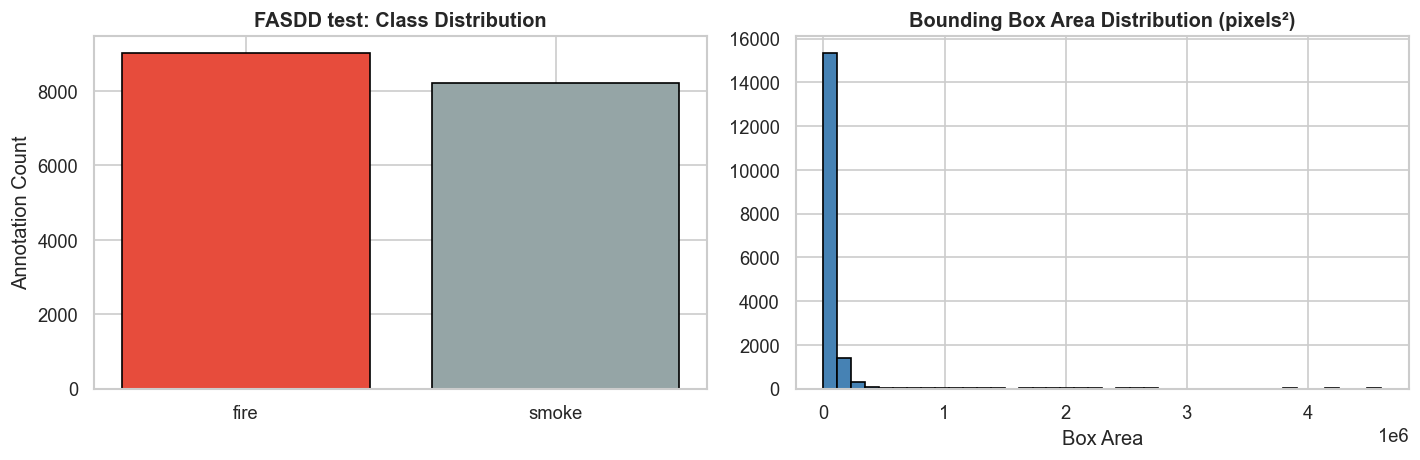

In [ ]:
# ── FASDD: Annotation statistics from full JSON ───────────────────────────────
ann_df = pd.DataFrame([{
    'image_id':    a['image_id'],
    'category_id': a['category_id'],
    'class_name':  categories[a['category_id']],
    'x': a['bbox'][0], 'y': a['bbox'][1],
    'w': a['bbox'][2], 'h': a['bbox'][3],
    'area': a['bbox'][2] * a['bbox'][3],
} for a in annotations])

print(f"FASDD {FASDD_SPLIT} split — annotation breakdown:")
print(ann_df.groupby('class_name').agg(count=('image_id','count'),
                                        mean_area=('area','mean')).round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
class_counts = ann_df['class_name'].value_counts()
axes[0].bar(class_counts.index, class_counts.values, color=['#e74c3c','#95a5a6'], edgecolor='black')
axes[0].set_title(f'FASDD {FASDD_SPLIT}: Class Distribution', fontweight='bold')
axes[0].set_ylabel('Annotation Count')

axes[1].hist(ann_df['area'], bins=40, color='steelblue', edgecolor='black')
axes[1].set_title('Bounding Box Area Distribution (pixels²)', fontweight='bold')
axes[1].set_xlabel('Box Area')

plt.tight_layout()
plt.savefig('fasdd_stats.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── FASDD: COCO → YOLO format converter ──────────────────────────────────────
# Run this at training time on the full downloaded dataset.
# For EDA we use the COCO JSON directly above.

def coco_to_yolo(coco_json_path, image_dir, output_label_dir):
    """
    Convert COCO bbox annotations to YOLO format txt files.
    COCO bbox: [x_min, y_min, width, height] (pixels)
    YOLO bbox: [class_id cx cy w h] (normalised 0-1)
    """
    with open(coco_json_path) as f:
        data = json.load(f)

    output_label_dir = Path(output_label_dir)
    output_label_dir.mkdir(parents=True, exist_ok=True)

    id_to_img  = {img['id']: img for img in data['images']}
    categories = {c['id']: idx for idx, c in enumerate(data['categories'])}

    # Group annotations by image
    img_anns = defaultdict(list)
    for ann in data['annotations']:
        img_anns[ann['image_id']].append(ann)

    for img_id, img_meta in id_to_img.items():
        W, H = img_meta['width'], img_meta['height']
        stem = Path(img_meta['file_name']).stem
        lines = []
        for ann in img_anns.get(img_id, []):
            cls_idx = categories[ann['category_id']]
            x, y, w, h = ann['bbox']
            cx = (x + w / 2) / W
            cy = (y + h / 2) / H
            nw = w / W
            nh = h / H
            lines.append(f"{cls_idx} {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}")
        with open(output_label_dir / f"{stem}.txt", 'w') as f:
            f.write("\n".join(lines))

    print(f"Converted {len(id_to_img)} images → YOLO labels in {output_label_dir}")

# Example (run at training time, NOT during EDA sampling):
# coco_to_yolo(
#     coco_json_path   = './datasets/fasdd_full/train/_annotations.coco.json',
#     image_dir        = './datasets/fasdd_full/train/images/',
#     output_label_dir = './datasets/fasdd_full/train/labels/',
# )
print("coco_to_yolo() converter loaded. Run at training time on the full dataset.")

coco_to_yolo() converter loaded. Run at training time on the full dataset.


---
### 2.6 FIRESENSE — Video-Based Dataset

**Origin:** EU FP7 Project. 49 video clips covering heritage buildings, urban environments, and some outdoor scenes.  
**Access:** Roboflow Universe or [mklab.iti.gr/firesense](http://mklab.iti.gr/firesense)

**Why this dataset:**  
Provides temporal/video data and hard negatives in urban settings. The `extract_frames()` utility (Section 0.1) is used to sample training frames from clips.  

**Classes:** `fire`, `smoke`  
**Format:** Video clips (`.avi` / `.mp4`); frame-level annotations + some bounding boxes

In [10]:
# ── FIRESENSE: Local Video-to-Frame Extraction ───────────────────────────────
# Updated to match your D: drive structure and category/subtype nesting

# 1. Set the correct Root Path (Pointing to your D: drive)
FIRESENSE_ROOT = Path(r"D:\datasets_dl\datasets\firesense")
FRAME_OUT_DIR  = DATASETS_DIR / 'firesense_frames'

# 2. Define the categories and subtypes as per your description
categories = ['fire', 'smoke']
subtypes   = ['pos', 'neg']

print(f"Scanning for videos in: {FIRESENSE_ROOT}")

# Since there are no images, we clear any previous logic looking for splits
# and instead extract frames from your video structure
for cat in categories:
    for typ in subtypes:
        # Build path: D:\datasets_dl\datasets\firesense\category\subtype
        video_subdir = FIRESENSE_ROOT / cat / typ
        
        if not video_subdir.exists():
            print(f"  Warning: Folder not found: {video_subdir}")
            continue
            
        # Find all .avi or .mp4 files in this specific subfolder
        videos = list(video_subdir.glob('*.avi')) + list(video_subdir.glob('*.mp4'))
        print(f"  Found {len(videos)} videos in {cat}/{typ}")
        
        for video_path in videos:
            # Create an output path that preserves the category and type
            # e.g., ./datasets/firesense_frames/smoke/neg/testneg01/
            out_dir = FRAME_OUT_DIR / cat / typ / video_path.stem
            
            # Use the extract_frames() utility loaded in Section 0.1
            extract_frames(
                video_path     = video_path,
                output_dir     = out_dir,
                every_n_frames = 30,    # Sample 1 frame per second (at 30fps)
                max_frames     = 50,    # Cap per video for this EDA deliverable
                prefix         = f"{cat}_{typ}_{video_path.stem}",
            )

# Final summary instead of checking for 'train/valid/test' image folders
total_frames = sum(1 for _ in FRAME_OUT_DIR.rglob('*.jpg'))
print(f"\nExtraction Complete.")
print(f"Total extracted images now available for visualization: {total_frames}")

Scanning for videos in: D:\datasets_dl\datasets\firesense
  Found 11 videos in fire/pos
  Video : posVideo1.868.avi
  Total : 293 frames @ 10.0 fps  (352x288)
  Saving: every 30 frames → ~9 output frames


100%|██████████| 293/293 [00:00<00:00, 1655.17frame/s]


  Saved : 10 frames → datasets\firesense_frames\fire\pos\posVideo1.868
  Video : posVideo10.869.avi
  Total : 235 frames @ 30.0 fps  (400x256)
  Saving: every 30 frames → ~7 output frames


100%|██████████| 235/235 [00:00<00:00, 2122.03frame/s]


  Saved : 8 frames → datasets\firesense_frames\fire\pos\posVideo10.869
  Video : posVideo11.870.avi
  Total : 178 frames @ 15.0 fps  (400x256)
  Saving: every 30 frames → ~5 output frames


...

  Saved : 26 frames → datasets\firesense_frames\smoke\neg\testneg07.813
  Video : testneg08.814.avi
  Total : 751 frames @ 25.0 fps  (352x288)
  Saving: every 30 frames → ~25 output frames


100%|██████████| 751/751 [00:00<00:00, 2373.60frame/s]


  Saved : 26 frames → datasets\firesense_frames\smoke\neg\testneg08.814
  Video : testneg09.815.avi
  Total : 723 frames @ 25.0 fps  (352x288)
  Saving: every 30 frames → ~24 output frames


100%|██████████| 723/723 [00:00<00:00, 3129.00frame/s]

  Saved : 25 frames → datasets\firesense_frames\smoke\neg\testneg09.815

Extraction Complete.
Total extracted images now available for visualization: 1049


In [11]:
# ── FIRESENSE: Nested Extraction for Local Folder Structure ──────────────────
FRAME_OUT_DIR = DATASETS_DIR / 'firesense_frames'

# Categories and subfolders as per your description
categories = ['fire', 'smoke']
subtypes   = ['pos', 'neg']

print(f"Scanning for videos in: {FIRESENSE_ROOT}")

for cat in categories:
    for typ in subtypes:
        # Construct the path to the specific video folder
        video_subdir = FIRESENSE_ROOT / cat / typ
        
        if not video_subdir.exists():
            continue
            
        # Find all .avi or .mp4 files in this subfolder
        videos = list(video_subdir.glob('*.avi')) + list(video_subdir.glob('*.mp4'))
        
        for video_path in videos:
            # Create an output path that preserves the category and type
            # e.g., ./datasets/firesense_frames/fire/pos/video_name/
            out_dir = FRAME_OUT_DIR / cat / typ / video_path.stem
            
            extract_frames(
                video_path     = video_path,
                output_dir     = out_dir,
                every_n_frames = 15,    # Sample ~2 fps
                max_frames     = 100,   # Cap for EDA visualization
                prefix         = f"{cat}_{typ}_{video_path.stem}",
            )

total_frames = sum(1 for _ in FRAME_OUT_DIR.rglob('*.jpg'))
print(f"\nTotal extracted frames across all categories: {total_frames}")

Scanning for videos in: D:\datasets_dl\datasets\firesense
  Video : posVideo1.868.avi
  Total : 293 frames @ 10.0 fps  (352x288)
  Saving: every 15 frames → ~19 output frames


100%|██████████| 293/293 [00:00<00:00, 1589.53frame/s]


  Saved : 20 frames → datasets\firesense_frames\fire\pos\posVideo1.868
  Video : posVideo10.869.avi
  Total : 235 frames @ 30.0 fps  (400x256)
  Saving: every 15 frames → ~15 output frames


100%|██████████| 235/235 [00:00<00:00, 1658.11frame/s]


  Saved : 16 frames → datasets\firesense_frames\fire\pos\posVideo10.869
  Video : posVideo11.870.avi
  Total : 178 frames @ 15.0 fps  (400x256)
  Saving: every 15 frames → ~11 output frames


...

  Saved : 52 frames → datasets\firesense_frames\smoke\neg\testneg07.813
  Video : testneg08.814.avi
  Total : 751 frames @ 25.0 fps  (352x288)
  Saving: every 15 frames → ~50 output frames


100%|██████████| 751/751 [00:00<00:00, 2240.75frame/s]


  Saved : 51 frames → datasets\firesense_frames\smoke\neg\testneg08.814
  Video : testneg09.815.avi
  Total : 723 frames @ 25.0 fps  (352x288)
  Saving: every 15 frames → ~48 output frames


100%|██████████| 723/723 [00:00<00:00, 1784.50frame/s]

  Saved : 49 frames → datasets\firesense_frames\smoke\neg\testneg09.815

Total extracted frames across all categories: 2075


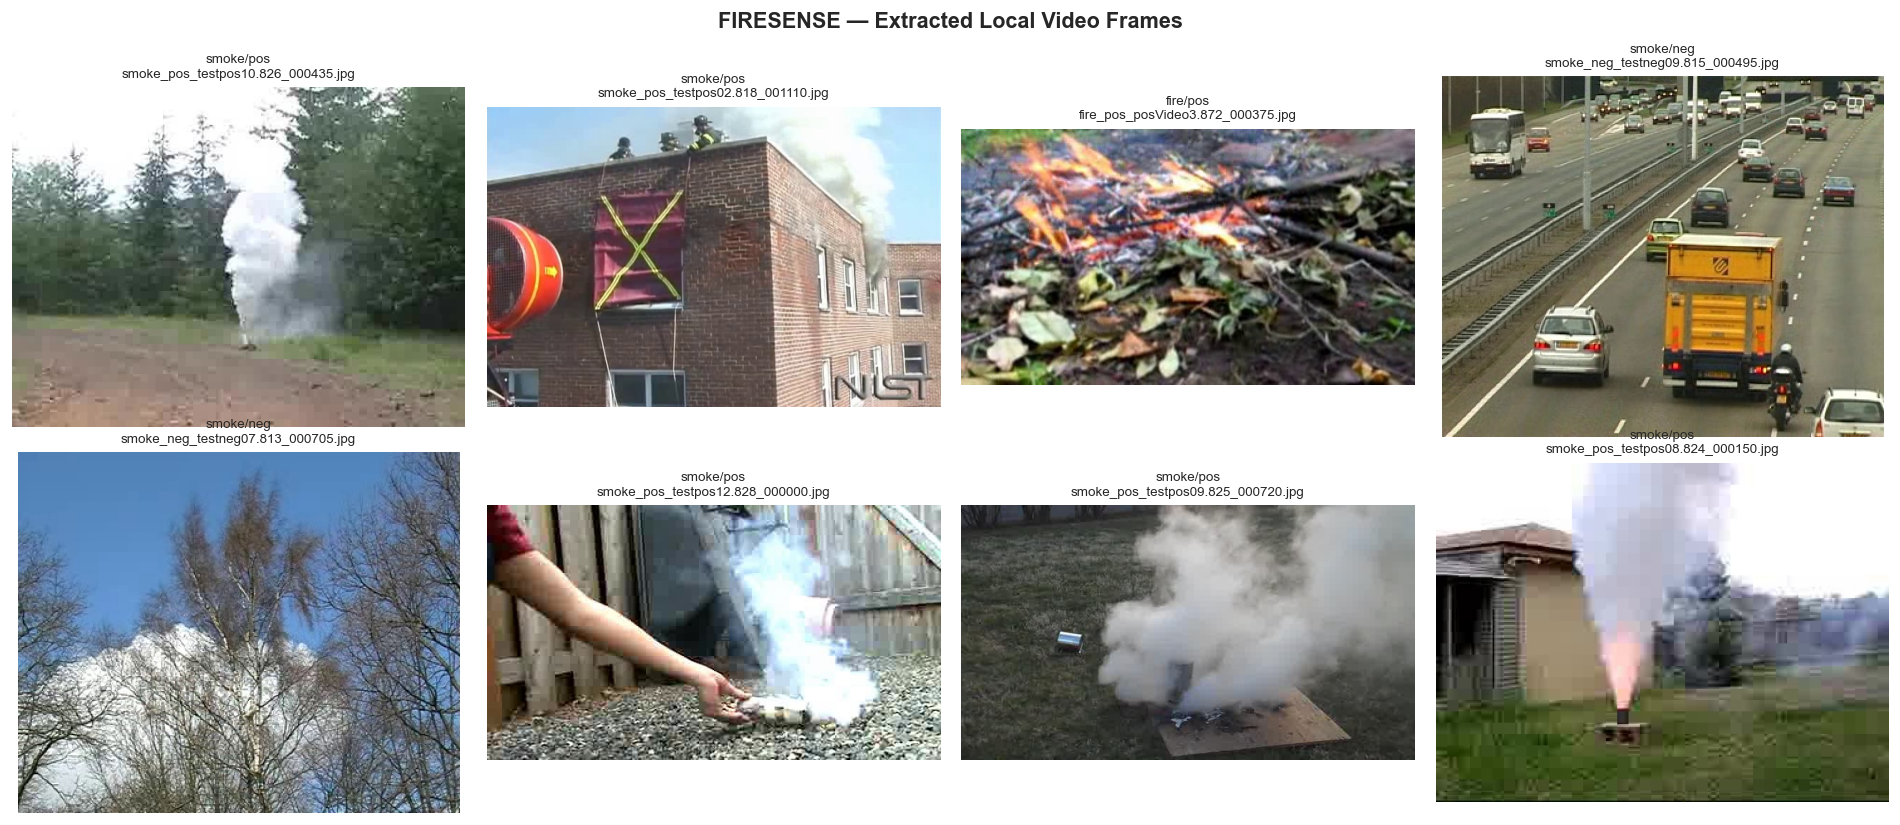

Showing 8 random samples from 2075 total extracted frames.


In [13]:
# ── FIRESENSE: Visualise Extracted Video Frames ──────────────────────────────
# Point to the local directory where extract_frames() saved the images
FRAME_OUT_DIR = DATASETS_DIR / 'firesense_frames'

# Recursively find all extracted .jpg files in the nested subfolders
all_extracted_imgs = list(FRAME_OUT_DIR.rglob('*.jpg'))

if all_extracted_imgs:
    # Randomly sample 8 images to display
    sample_size = min(8, len(all_extracted_imgs))
    sample = random.sample(all_extracted_imgs, sample_size)
    
    fig, axes = plt.subplots(2, 4, figsize=(16, 7))
    fig.suptitle('FIRESENSE — Extracted Local Video Frames', fontsize=13, fontweight='bold')

    for ax, img_path in zip(axes.flat, sample):
        # Load and convert for plotting
        img = cv2.imread(str(img_path))
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            ax.imshow(img)
            
            # Show the category/type in the title (parsed from the path)
            # Path structure: .../firesense_frames/category/type/video_name/frame.jpg
            parts = img_path.parts
            category = parts[-4] # 'fire' or 'smoke'
            label_type = parts[-3] # 'pos' or 'neg'
            ax.set_title(f"{category}/{label_type}\n{img_path.name}", fontsize=8)
        
        ax.axis('off')

    plt.tight_layout()
    plt.savefig('firesense_local_samples.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"Showing {sample_size} random samples from {len(all_extracted_imgs)} total extracted frames.")
else:
    print(f"No frames found in {FRAME_OUT_DIR}. Ensure you ran the extraction block above.")

---
## 3. Stage 2 — Nighttime Fine-tuning: FLAME 2

**Origin:** *FLAME 2: FIRE Detection and Modeling* — IEEE DataPort. Collected using DJI Phantom UAVs with paired RGB and FLIR thermal cameras during controlled wildfire experiments.

**Why this dataset:**  
FLAME 2 is the only publicly available dataset with paired RGB + IR sequences from actual wildfire events. Used in Stage 2 to fine-tune on heat-signature-based detection.

**Classes:** Binary — `fire` / `no fire` (image-level) + segmentation masks  
**Access:** [IEEE DataPort](https://ieee-dataport.org/open-access/flame-2-fire-detection-and-modeling-dataset) (free IEEE account)

In [ ]:
# ── FLAME 2: Repository structure ────────────────────────────────────────────
flame2 = pd.DataFrame([
    {'Repository': '1 — RGB Video 1 (Zenmuse X4S)',     'Duration': '16 min', 'FPS': 29, 'Res': '1280x720',  'Modality': 'RGB'},
    {'Repository': '2 — RGB Video 2 (Zenmuse X4S)',     'Duration': '16 min', 'FPS': 29, 'Res': '1280x720',  'Modality': 'RGB'},
    {'Repository': '3 — IR WhiteHot',                   'Duration': '89 s',   'FPS': 30, 'Res': '640x512',   'Modality': 'Thermal IR'},
    {'Repository': '4 — IR GreenHot',                   'Duration': '5 min',  'FPS': 30, 'Res': '640x512',   'Modality': 'Thermal IR'},
    {'Repository': '5 — IR Fusion Heatmap',             'Duration': '25 min', 'FPS': 30, 'Res': '640x512',   'Modality': 'Thermal IR'},
    {'Repository': '6 — 4K RGB (DJI Phantom 3)',        'Duration': '17 min', 'FPS': 30, 'Res': '3840x2160', 'Modality': 'RGB'},
    {'Repository': '7 — Classification images (train)', 'Duration': 'N/A',    'FPS': 'N/A', 'Res': '254x254', 'Modality': 'RGB'},
    {'Repository': '8 — Classification images (test)',  'Duration': 'N/A',    'FPS': 'N/A', 'Res': '254x254', 'Modality': 'RGB'},
    {'Repository': '9 — Segmentation images',           'Duration': 'N/A',    'FPS': 'N/A', 'Res': 'High-res','Modality': 'RGB'},
    {'Repository': '10 — Segmentation masks',           'Duration': 'N/A',    'FPS': 'N/A', 'Res': 'High-res','Modality': 'Binary mask'},
])
print('FLAME 2 — Repository Structure (from paper)')
flame2

In [ ]:
# ── FLAME 2: Extract frames from RGB/IR video clips ──────────────────────────
# After downloading from IEEE DataPort, use extract_frames() to pull training frames.
# FLAME 2 video files are typically .mp4 or .avi.

# Example — process all RGB clips:
# FLAME2_VIDEO_DIR  = Path('./datasets/flame2/videos')
# FLAME2_FRAME_DIR  = Path('./datasets/flame2/frames')

# for video_path in sorted(FLAME2_VIDEO_DIR.glob('*.mp4')):
#     modality = 'ir' if 'IR' in video_path.name.upper() else 'rgb'
#     out_dir  = FLAME2_FRAME_DIR / modality / video_path.stem
#     extract_frames(
#         video_path     = video_path,
#         output_dir     = out_dir,
#         every_n_frames = 30,    # 1fps from 30fps video
#         max_frames     = 500,
#         prefix         = f"{modality}_{video_path.stem}",
#     )

flame2_clf = pd.DataFrame([
    {'Split': 'Train', 'Fire images': 23022, 'No-fire images': 16353, 'Total': 39375},
    {'Split': 'Test',  'Fire images':  8617, 'No-fire images':     0, 'Total':  8617},
])
print('FLAME 2 — Classification Task Split (repositories 7 & 8)')
print(flame2_clf.to_string(index=False))
print()
print('Note: test set contains ONLY fire images — evaluation is recall-focused.')

In [ ]:
# ── FLAME 2: Synthetic nighttime augmentation demo ────────────────────────────
def apply_nighttime_augmentation(img_bgr, seed=None):
    """Synthetic nighttime augmentation for fire/smoke images."""
    rng = np.random.default_rng(seed)
    img = img_bgr.astype(np.float32)
    fire_mask = (img[:,:,2] > 150) & (img[:,:,0] < 100)   # BGR: high R, low B
    dark_factor = rng.uniform(0.12, 0.28)
    img = img * dark_factor
    img[:,:,0] = np.clip(img[:,:,0] * 1.15, 0, 255)        # blue tint
    noise = rng.normal(0, 12, img.shape)
    img = np.clip(img + noise, 0, 255)
    restore = rng.uniform(0.55, 0.75)
    img[fire_mask] = img_bgr.astype(np.float32)[fire_mask] * restore
    img_u8 = img.astype(np.uint8)
    lab = cv2.cvtColor(img_u8, cv2.COLOR_BGR2LAB)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    lab[:,:,0] = clahe.apply(lab[:,:,0])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

# Demo on D-Fire images (no FLAME 2 download needed for this visualisation)
train_imgs = sorted((DFIRE_ROOT / 'train' / 'images').glob('*.jpg'))
sample_paths = random.sample(train_imgs, min(4, len(train_imgs)))

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle('Synthetic Nighttime Augmentation — Applied to D-Fire Training Images',
             fontsize=12, fontweight='bold')

for i, img_path in enumerate(sample_paths):
    orig_bgr = cv2.imread(str(img_path))
    aug_bgr  = apply_nighttime_augmentation(orig_bgr, seed=i)
    axes[0, i].imshow(cv2.cvtColor(orig_bgr, cv2.COLOR_BGR2RGB))
    axes[0, i].set_title('Original', fontsize=9); axes[0, i].axis('off')
    axes[1, i].imshow(cv2.cvtColor(aug_bgr,  cv2.COLOR_BGR2RGB))
    axes[1, i].set_title('Augmented (Night)', fontsize=9, color='navy'); axes[1, i].axis('off')

plt.tight_layout()
plt.savefig('nighttime_augmentation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Stage 3 — Domain Adaptation (WWF Custom Dataset)

### 4.1 Custom Dataset Strategy & Annotation Protocol
The final stage of our project involves adapting the models trained in Stages 1 and 2 to the specific environmental conditions of the Margalla Hills and surrounding areas using PTZ (Pan-Tilt-Zoom) footage.

**Current Status: Active Protocol Development**
While we are currently streamlining the footage acquisition pipeline, we have already initiated work on the annotation infrastructure. Our team is actively addressing several key roadblocks identified during the proxy-testing phase:

1.  **The Mist/Smoke Confusion:** We are developing a robust visual protocol to distinguish morning mist and clouds from low-intensity smoke. This involves a "Hard Negative" labeling strategy where horizon-level clouds are treated as a distinct class to reduce false positives.
2.  **Geographic Domain Gap:** To bridge the gap between European/American datasets and South Asian terrain, we are sourcing footage that specifically captures the high-frequency textures of local vegetation.
3.  **Annotation Consistency:** We have established a multi-pass labeling workflow. For every frame, an initial automated proposal is generated using our Stage 1 model, followed by manual verification and correction to ensure pixel-perfect bounding boxes.

### 4.2 Annotation Work & Methodology
Our annotation effort is not merely about drawing boxes but about building a site-specific intelligence layer.

* **Tooling:** We are utilizing standardized platforms to manage the versioning of our custom labels.
* **3-Class Schema:** We have moved beyond binary detection to a 3-class system (**Fire, Smoke, Cloud**). By explicitly labeling clouds, we force the model to learn the specific motion and edge characteristics of smoke versus weather patterns.
* **Temporal Context:** For the PTZ footage, our annotation protocol includes labeling "Ignition Sequences"—capturing the very first frames of smoke appearance to optimize the model for early-warning speed.

In [ ]:
# ── Section 4.1: WWF Custom Dataset Technical Status ─────────────────────────
wwf_status = {
    'Project Phase': 'Active Infrastructure & Protocol Setup',
    'Primary Roadblock': 'Mitigating Cloud/Mist False Positives in PTZ Horizon Views',
    'Annotation Protocol': 'Standardized 3-Class Labeling (Fire, Smoke, Cloud)',
    'Workflow Status': [
        'Infrastructure configured for team-based annotation',
        'Visual protocol established for edge-case resolution',
        'Baseline Stage 1 model ready for auto-labeling assistance'
    ]
}

print('=== Stage 3: WWF Custom Dataset Documentation ===')
for k, v in wwf_status.items():
    if isinstance(v, list):
        print(f'\n  {k}:')
        for item in v:
            print(f'    - {item}')
    else:
        print(f'  {k:<20}: {v}')

In [ ]:
# ── WWF Dataset: Projected split strategy ────────────────────────────────────
wwf_split_plan = pd.DataFrame([
    {'Split': 'Train', 'Camera sites': 'Sites A, B, C',     'Approx frames': '~600',
     'Conditions': 'Daytime + synthetic night', 'Notes': 'Multi-condition augmentation'},
    {'Split': 'Val',   'Camera sites': 'Site D',            'Approx frames': '~150',
     'Conditions': 'Daytime',                  'Notes': 'Tune decision thresholds'},
    {'Split': 'Test',  'Camera sites': 'Site E (held out)', 'Approx frames': '~250',
     'Conditions': 'Daytime + dawn/dusk',      'Notes': 'Geographic leakage prevention'},
])
print('WWF PTZ Dataset — Projected Split Strategy')
wwf_split_plan.set_index('Split')

---
## 5. Cross-Dataset Analysis

In [ ]:
# ── Gap coverage matrix ───────────────────────────────────────────────────────
gap_matrix = pd.DataFrame([
    {'Dataset': 'D-Fire',          'Edge benchmark': '✓', 'Cloud hard neg.': '✗', 'Nighttime': '✗', 'Fixed camera': '✗', 'S. Asian terrain': '✗'},
    {'Dataset': 'FIgLib',          'Edge benchmark': '~', 'Cloud hard neg.': '~', 'Nighttime': '✗', 'Fixed camera': '✓', 'S. Asian terrain': '✗'},
    {'Dataset': 'FASDD',           'Edge benchmark': '~', 'Cloud hard neg.': '✗', 'Nighttime': '✗', 'Fixed camera': '✗', 'S. Asian terrain': '~'},
    {'Dataset': 'FIRESENSE',       'Edge benchmark': '✗', 'Cloud hard neg.': '✗', 'Nighttime': '✗', 'Fixed camera': '✗', 'S. Asian terrain': '✗'},
    {'Dataset': 'FLAME 2',         'Edge benchmark': '✗', 'Cloud hard neg.': '✗', 'Nighttime': '✓', 'Fixed camera': '✗', 'S. Asian terrain': '✗'},
    {'Dataset': 'WWF (Custom)',    'Edge benchmark': '✓', 'Cloud hard neg.': '✓', 'Nighttime': '✓', 'Fixed camera': '✓', 'S. Asian terrain': '✓'},
])
gap_matrix.set_index('Dataset', inplace=True)
print('Gap Coverage Matrix   ✓=addressed  ~=partial  ✗=not addressed')
gap_matrix

In [ ]:
# ── Three-stage pipeline visualisation ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.axis('off')

stages = [
    ('Stage 1\nPretraining',
     'D-Fire + FIgLib\n+ FASDD + FIRESENSE',
     '#2980b9', 0.05),
    ('Stage 2\nNighttime\nFine-tuning',
     'FLAME 2\n(RGB + IR)\n+ Synthetic Night Aug.',
     '#8e44ad', 0.40),
    ('Stage 3\nDomain\nAdaptation',
     'WWF PTZ\nCustom Dataset\n(South Asian terrain)',
     '#27ae60', 0.73),
]

for title, data, color, x in stages:
    rect = patches.FancyBboxPatch((x, 0.1), 0.24, 0.8,
                                  boxstyle='round,pad=0.02',
                                  linewidth=2, edgecolor=color,
                                  facecolor=color + '22')
    ax.add_patch(rect)
    ax.text(x + 0.12, 0.83, title, ha='center', va='top',
            fontsize=11, fontweight='bold', color=color)
    ax.text(x + 0.12, 0.58, data,  ha='center', va='top',
            fontsize=9, color='#2c3e50', linespacing=1.5)
    if x < 0.73:
        ax.annotate('', xy=(x + 0.27, 0.5), xytext=(x + 0.245, 0.5),
                    arrowprops=dict(arrowstyle='->', color='#7f8c8d', lw=2))

ax.text(0.5, 0.02, 'Sequential staged fine-tuning — each stage inherits weights from the previous',
        ha='center', fontsize=9, style='italic', color='#7f8c8d', transform=ax.transAxes)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_title('Three-Stage Training Pipeline — Dataset Flow', fontsize=13, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('training_pipeline.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Dataset Strategy Summary

| Aspect | Decision | Rationale |
|---|---|---|
| **Primary eval benchmark** | D-Fire | Standard compact-model benchmark; fire + smoke; YOLO format |
| **PTZ-analogue pretraining** | FIgLib | Only public fixed-camera forest smoke dataset |
| **Nighttime fine-tuning** | FLAME 2 | Only public RGB+IR paired wildfire dataset |
| **Generalisation test** | FASDD | Broadest geographic diversity; COCO format |
| **Hard negative strategy** | Cloud class in WWF + FIRESENSE hard negatives | SOA gap: 30-40% FP reduction with explicit hard negatives |
| **Domain gap solution** | WWF custom annotations | No public dataset covers South Asian PTZ forest footage |
| **Annotation format** | YOLO (train stages); COCO→YOLO conversion for FASDD | Direct compatibility with YOLOv8 training loop |
| **Video frames** | `extract_frames()` utility | Reusable for FIRESENSE, FLAME 2 raw clips |
| **Test leakage prevention** | Hold out one full camera site | Prevent geographic inflation of test metrics |

In [ ]:
# ── Final: Dataset size comparison (log scale) ────────────────────────────────
sizes = {
    'D-Fire':         21527,
    'FIgLib':         24800,
    'FIRESENSE':      25000,
    'FASDD':         120000,
    'FLAME 2 (clf)':  48000,
    'WWF (TBD)':       1000,
}

fig, ax = plt.subplots(figsize=(11, 5))
colors_map = {
    'D-Fire': '#2980b9', 'FIgLib': '#2980b9', 'FASDD': '#2980b9',
    'FIRESENSE': '#2980b9',
    'FLAME 2 (clf)': '#8e44ad',
    'WWF (TBD)': '#27ae60',
}
bar_colors = [colors_map[k] for k in sizes]
bars = ax.barh(list(sizes.keys()), list(sizes.values()),
               color=bar_colors, edgecolor='black', linewidth=0.6)
ax.set_xscale('log')
ax.set_xlabel('Number of Images (log scale)')
ax.set_title('Dataset Sizes Across All Stages', fontweight='bold')
for bar, val in zip(bars, sizes.values()):
    ax.text(val * 1.05, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=8)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2980b9', label='Stage 1 — Pretraining'),
    Patch(facecolor='#8e44ad', label='Stage 2 — Nighttime Fine-tuning'),
    Patch(facecolor='#27ae60', label='Stage 3 — Domain Adaptation (WWF)'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig('dataset_sizes.png', dpi=150, bbox_inches='tight')
plt.show()